✅ Отдельные графики сохранены в 'individual_losses.png'


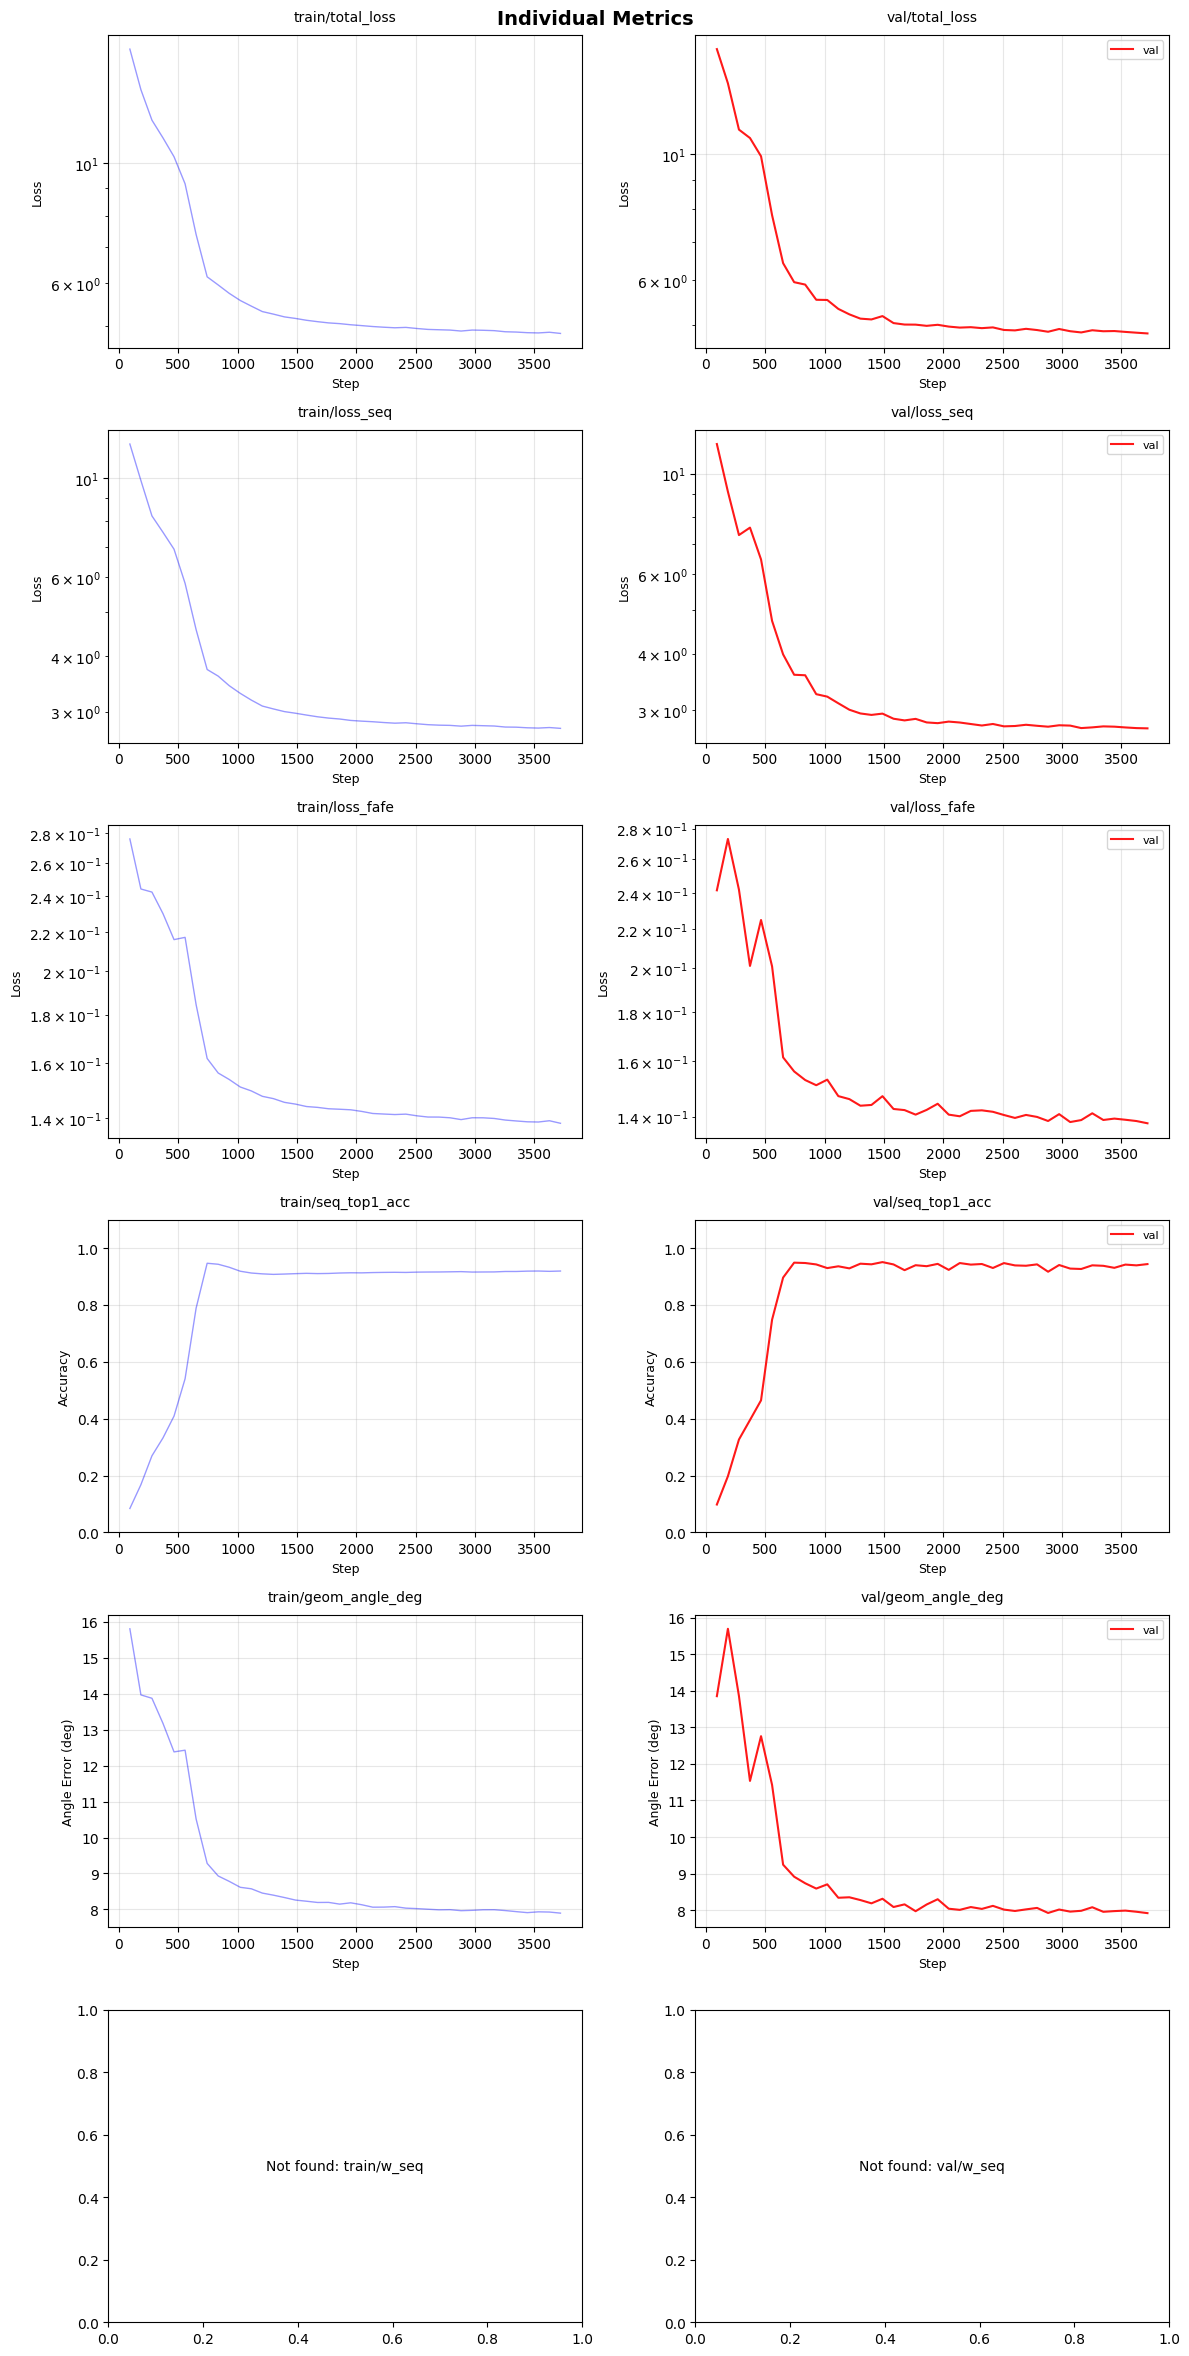

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def _find_metric_column(df, metric_name, prefer_epoch=True):
    """
    Ищет колонку метрики в формате Lightning:
    - train: train/metric_epoch, train/metric_step
    - val/test: val/metric (без суффикса)
    """
    # 1. Точное совпадение (для val/test)
    if metric_name in df.columns:
        return metric_name
    
    # 2. Для train: пробуем суффиксы в правильном порядке
    if prefer_epoch and f"{metric_name}_epoch" in df.columns:
        return f"{metric_name}_epoch"
    if f"{metric_name}_step" in df.columns:
        return f"{metric_name}_step"
    # Фолбэк: если prefer_epoch=False, но есть _epoch
    if f"{metric_name}_epoch" in df.columns:
        return f"{metric_name}_epoch"
    
    return None


def plot_training_logs(logs_dir="csv_logs/mlp_mixer/", version="version_118"):
    csv_path = os.path.join(logs_dir, version, "metrics.csv")
    if not os.path.exists(csv_path):
        print(f"❌ Файл {csv_path} не найден!")
        return

    df = pd.read_csv(csv_path)
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    fig.suptitle("Training Metrics — MLP Mixer", fontsize=14, fontweight='bold')

    # ✅ МЕТРИКИ, КОТОРЫЕ РЕАЛЬНО ЛОГИРУЮТСЯ в _shared_forward
    metrics = [
        ("train/total_loss", "val/total_loss", None, "TRAIN: total_loss", True),
        ("train/loss_seq", "val/loss_seq", None, "TRAIN: loss_seq", True),
        ("train/loss_fafe", "val/loss_fafe", None, "TRAIN: loss_fafe", True),
        ("train/seq_top1_acc", "val/seq_top1_acc", None, "TRAIN: seq_top1_acc", False),
        ("train/geom_angle_deg", "val/geom_angle_deg", None, "TRAIN: geom_angle_deg", False),
        ("train/w_seq", "val/w_seq", None, "TRAIN: w_seq", True),
    ]

    for idx, (train_metric, val_metric, test_metric, train_title, use_log) in enumerate(metrics):
        row, col = idx // 3, idx % 3
        ax = axes[row, col]
        handles, labels = [], []

        # --- Train (синий) ---
        train_col = _find_metric_column(df, train_metric, prefer_epoch=True)
        if train_col and train_col in df.columns:
            train_df = df.dropna(subset=['step', train_col])
            if len(train_df) > 0:
                line, = ax.plot(train_df['step'], train_df[train_col], 
                                'b-', alpha=0.4, linewidth=1, label='train')
                handles.append(line)
                labels.append('train')

        # --- Val (красный) ---
        val_col = _find_metric_column(df, val_metric, prefer_epoch=False)
        if val_col and val_col in df.columns:
            val_df = df.dropna(subset=['step', val_col])
            if len(val_df) > 0:
                line, = ax.plot(val_df['step'], val_df[val_col], 
                                'r-', alpha=0.9, linewidth=1.5, label='val')
                handles.append(line)
                labels.append('val')

        if handles:
            ax.legend(handles, labels, fontsize=8, loc='best')

        ax.set_xlabel("Step", fontsize=9)
        ax.set_ylabel("Value" if not use_log else "Loss (log scale)", fontsize=9)
        ax.set_title(train_title, fontsize=10, pad=10)
        ax.grid(True, alpha=0.3)
        
        if use_log:
            ax.set_yscale('log')
        elif 'acc' in train_metric:
            ax.set_ylim(0, 1.1)

    plt.tight_layout()
    plt.savefig("training_metrics.png", dpi=370, bbox_inches='tight')
    print("✅ Графики сохранены в 'training_metrics.png'")
    plt.show()


def plot_individual_losses(logs_dir="csv_logs/mlp_mixer/", version="version_118"):
    csv_path = os.path.join(logs_dir, version, "metrics.csv")
    if not os.path.exists(csv_path):
        print(f"❌ Файл {csv_path} не найден!")
        return

    df = pd.read_csv(csv_path)
    
    # ✅ ТОЛЬКО РЕАЛЬНЫЕ МЕТРИКИ (без суффиксов для val, с авто-поиском для train)
    metrics_to_plot = [
        "train/total_loss", "val/total_loss",
        "train/loss_seq", "val/loss_seq",
        "train/loss_fafe", "val/loss_fafe",
        "train/seq_top1_acc", "val/seq_top1_acc",
        "train/geom_angle_deg", "val/geom_angle_deg",
        "train/w_seq", "val/w_seq",
    ]

    # Динамическая сетка
    n_metrics = len(metrics_to_plot)
    n_cols = 2
    n_rows = (n_metrics + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    fig.suptitle("Individual Metrics", fontsize=14, fontweight='bold')

    # Нормализация axes для индексации [row, col]
    if n_rows == 1:
        axes = [axes]
    elif n_cols == 1:
        axes = [[ax] for ax in axes]

    for idx, metric in enumerate(metrics_to_plot):
        row = idx // n_cols
        col = idx % n_cols
        ax = axes[row, col]

        prefer_epoch = metric.startswith("train/")
        actual_col = _find_metric_column(df, metric, prefer_epoch=prefer_epoch)
        
        if actual_col and actual_col in df.columns:
            plot_df = df.dropna(subset=['step', actual_col])
            if len(plot_df) > 0:
                steps = plot_df['step'].values
                values = plot_df[actual_col].values
                
                if 'train' in metric:
                    color, label, alpha, lw = 'blue', 'train', 0.4, 1
                    marker = None
                else:  # val
                    color, label, alpha, lw = 'red', 'val', 0.9, 1.5
                    marker = None
                
                ax.plot(steps, values, color=color, linewidth=lw, alpha=alpha, label=label, marker=marker, markersize=3)
                ax.set_xlabel("Step", fontsize=9)
                
                if 'acc' in metric:
                    ax.set_ylabel("Accuracy", fontsize=9)
                    ax.set_ylim(0, 1.1)
                elif 'angle' in metric:
                    ax.set_ylabel("Angle Error (deg)", fontsize=9)
                elif 'w_' in metric:
                    ax.set_ylabel("Weight", fontsize=9)
                else:
                    ax.set_ylabel("Loss", fontsize=9)
                    ax.set_yscale('log')
                
                ax.set_title(metric, fontsize=10, pad=10)
                ax.grid(True, alpha=0.3)
                if col == n_cols - 1:  # легенда только в правой колонке
                    ax.legend(fontsize=8, loc='best')
            else:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        else:
            ax.text(0.5, 0.5, f'Not found: {metric}', ha='center', va='center', transform=ax.transAxes)

    # Убираем пустые подграфики
    for idx in range(n_metrics, n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.savefig("individual_losses.png", dpi=300, bbox_inches='tight')
    print("✅ Отдельные графики сохранены в 'individual_losses.png'")
    plt.show()


def plot_validation_logs(logs_dir="csv_logs/mlp_mixer/", version="version_118"):
    csv_path = os.path.join(logs_dir, version, "metrics.csv")
    if not os.path.exists(csv_path):
        print(f"❌ Файл {csv_path} не найден!")
        return

    df = pd.read_csv(csv_path)
    
    # ✅ ТОЛЬКО ВАЛИДАЦИОННЫЕ МЕТРИКИ (без суффиксов)
    val_metrics = [
        ("val/total_loss", "VAL: total_loss", True),
        ("val/loss_seq", "VAL: loss_seq", True),
        ("val/loss_fafe", "VAL: loss_fafe", True),
        ("val/seq_top1_acc", "VAL: seq_top1_acc", False),
        ("val/geom_angle_deg", "VAL: geom_angle_deg", False),
        ("val/w_seq", "VAL: w_seq", True),
    ]

    n_metrics = len(val_metrics)
    n_cols = 2
    n_rows = (n_metrics + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    fig.suptitle("Validation Metrics — MLP Mixer", fontsize=16, fontweight='bold', y=1.02)

    # Нормализация axes
    if n_rows == 1:
        axes = [axes]
    elif n_cols == 1:
        axes = [[ax] for ax in axes]

    for idx, (metric_name, title, use_log) in enumerate(val_metrics):
        row = idx // n_cols
        col = idx % n_cols
        ax = axes[row, col]
        
        actual_col = _find_metric_column(df, metric_name, prefer_epoch=False)
        
        if actual_col and actual_col in df.columns:
            plot_df = df.dropna(subset=['step', actual_col])
            if len(plot_df) > 0:
                steps = plot_df['step'].values
                values = plot_df[actual_col].values
                
                ax.plot(steps, values, 'r-', linewidth=2, alpha=0.9, label='val')
                
                ax.set_xlabel("Step", fontsize=10)
                if 'acc' in metric_name:
                    ax.set_ylabel("Accuracy", fontsize=10)
                    ax.set_ylim(0, 1.1)
                elif 'angle' in metric_name:
                    ax.set_ylabel("Angle Error (deg)", fontsize=10)
                elif 'w_' in metric_name:
                    ax.set_ylabel("Weight", fontsize=10)
                else:
                    ax.set_ylabel("Loss", fontsize=10)
                    if use_log:
                        ax.set_yscale('log')
                
                ax.set_title(title, fontsize=11, pad=12, fontweight='semibold')
                ax.grid(True, alpha=0.3, linestyle='--')
                ax.legend(fontsize=9, loc='best')
                
                if len(values) > 0:
                    final_val = values[-1]
                    ax.text(0.98, 0.02, f'final: {final_val:.4g}', 
                           transform=ax.transAxes, fontsize=8, 
                           ha='right', va='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
            else:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', 
                       transform=ax.transAxes, fontsize=10)
        else:
            ax.text(0.5, 0.5, f'Not found:\n{metric_name}', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=9)

    plt.tight_layout()
    plt.savefig("validation_metrics.png", dpi=300, bbox_inches='tight')
    print("✅ Графики валидации сохранены в 'validation_metrics.png'")
    plt.show()


if __name__ == "__main__":
    # plot_training_logs()
    # plot_validation_logs()
    plot_individual_losses()